## Model v4 + Frozen Classifier Feature Loss

## 1. Google Drive + vtac 설정

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, time
VTAC_ZIP = '/content/drive/MyDrive/vtac.zip'
VTAC_OUT = '/content/vtac_unzipped'

if not os.path.exists(VTAC_OUT) or len(os.listdir(VTAC_OUT)) == 0:
    print('vtac.zip 복사 중...')
    t0 = time.time()
    os.makedirs(VTAC_OUT, exist_ok=True)
    os.system(f'cp "{VTAC_ZIP}" /content/vtac.zip')
    os.system(f'unzip -q /content/vtac.zip -d {VTAC_OUT}')
    print(f'완료! ({time.time()-t0:.0f}초)')
else:
    print('이미 압축 해제됨 — 건너뜀')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
이미 압축 해제됨 — 건너뜀


## 2. Import

In [4]:
!pip install PyWavelets scikit-learn -q

import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pywt
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

SEED = 42
def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.backends.cudnn.benchmark = True
print('device:', device)


device: cuda


## 3. 경로 설정

In [5]:
DATA_DIR = '/content/drive/MyDrive/vtac_preprocessed_10s_v2'
TRAIN_PT = f'{DATA_DIR}/train_10s_v2.pt'
VAL_PT   = f'{DATA_DIR}/val_10s_v2.pt'
TEST_PT  = f'{DATA_DIR}/test_10s_v2.pt'

# 기존 baseline 결과와 섞이지 않게 별도 output directory 사용
OUT_DIR = '/content/drive/MyDrive/vtac_project/outputs/cvae_v4_classifier_physloss'
os.makedirs(OUT_DIR, exist_ok=True)

# Classifier2.ipynb에서 학습/저장한 frozen auxiliary classifier checkpoint
AUX_PHYS_CKPT_PATH = '/content/drive/MyDrive/vtac_project/outputs/masked_multimodal_resnet_tcn_classifier/masked_multimodal_resnet_tcn_best.pt'

print('DATA_DIR:', DATA_DIR)
print('OUT_DIR:', OUT_DIR)
print('AUX_PHYS_CKPT_PATH:', AUX_PHYS_CKPT_PATH)
!ls -lh "{DATA_DIR}" 2>/dev/null || echo '❌ Preprocess_v2.ipynb 먼저 실행하세요'
!ls -lh "{AUX_PHYS_CKPT_PATH}" 2>/dev/null || echo '⚠️ Classifier2.ipynb를 먼저 실행하거나 AUX_PHYS_CKPT_PATH를 수정하세요'

DATA_DIR: /content/drive/MyDrive/vtac_preprocessed_10s_v2
OUT_DIR: /content/drive/MyDrive/vtac_project/outputs/cvae_v4_classifier_physloss
AUX_PHYS_CKPT_PATH: /content/drive/MyDrive/vtac_project/outputs/masked_multimodal_resnet_tcn_classifier/masked_multimodal_resnet_tcn_best.pt
total 187M
-rw------- 1 root root  18M Jun  1 17:50 test_10s_v2.pt
-rw------- 1 root root 151M Jun  1 17:50 train_10s_v2.pt
-rw------- 1 root root  19M Jun  1 17:50 val_10s_v2.pt
-rw------- 1 root root 19M Jun 19 11:11 /content/drive/MyDrive/vtac_project/outputs/masked_multimodal_resnet_tcn_classifier/masked_multimodal_resnet_tcn_best.pt


## 4. 데이터 로드

In [6]:
def safe_load(path):
    try:    return torch.load(path, map_location='cpu', weights_only=False)
    except: return torch.load(path, map_location='cpu')

def load_split(path):
    d = safe_load(path)
    X, y, m = d['X'].float(), d['y'].long(), d['m_channel'].float()
    print(path.split('/')[-1], '| X:', tuple(X.shape),
          '| label:', torch.bincount(y, minlength=2).tolist(),
          '| ch avail:', m.sum(0).long().tolist())
    return X, y, m, d

X_train, y_train, m_train, _ = load_split(TRAIN_PT)
X_val,   y_val,   m_val,   _ = load_split(VAL_PT)
X_test,  y_test,  m_test,  _ = load_split(TEST_PT)
CHANNELS = ['ECG1', 'ECG2', 'PPG', 'ABP']


train_10s_v2.pt | X: (3901, 4, 2500) | label: [2754, 1147] | ch avail: [3901, 3901, 3572, 1393]
val_10s_v2.pt | X: (481, 4, 2500) | label: [341, 140] | ch avail: [481, 481, 445, 171]
test_10s_v2.pt | X: (465, 4, 2500) | label: [328, 137] | ch avail: [465, 465, 425, 171]


## 5. Dataset + DataLoader

In [7]:
C_DIM = 5; LATENT_DIM = 128; BATCH_SIZE = 64; SEQ_LEN = 2500

def make_cond(y, m):
    return torch.cat([y.float().unsqueeze(1), m.float()], dim=1)

c_train = make_cond(y_train, m_train)
c_val   = make_cond(y_val,   m_val)
c_test  = make_cond(y_test,  m_test)

train_ds = TensorDataset(X_train, c_train, m_train)
val_ds   = TensorDataset(X_val,   c_val,   m_val)

cw = 1.0 / torch.bincount(y_train, minlength=2).float()
sampler = WeightedRandomSampler(cw[y_train], len(y_train), replacement=True)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('train:', len(train_ds), '| val:', len(val_ds))


train: 3901 | val: 481


## 6. 모델 아키텍처
### 6-1. ConvBranchEncoder

In [8]:
class ConvBranchEncoder(nn.Module):
    def __init__(self, in_wave_channels, c_dim, hidden_channels=(32,64,128),
                 out_dim=256, seq_len=2500, norm_groups=8):
        super().__init__()
        self.c_dim   = c_dim
        self.seq_len = seq_len
        ic = in_wave_channels + c_dim

        def gn(ch):
            g = min(norm_groups, ch)
            while ch % g: g -= 1
            return nn.GroupNorm(g, ch)

        self.conv = nn.Sequential(
            nn.Conv1d(ic, hidden_channels[0], 9, stride=2, padding=4), gn(hidden_channels[0]), nn.SiLU(),
            nn.Conv1d(hidden_channels[0], hidden_channels[1], 9, stride=2, padding=4), gn(hidden_channels[1]), nn.SiLU(),
            nn.Conv1d(hidden_channels[1], hidden_channels[2], 7, stride=2, padding=3), gn(hidden_channels[2]), nn.SiLU(),
            nn.Conv1d(hidden_channels[2], hidden_channels[2], 7, stride=1, padding=3), gn(hidden_channels[2]), nn.SiLU(),
        )
        with torch.no_grad():
            d = torch.zeros(1, in_wave_channels + c_dim, seq_len)
            self.flat_dim = self.conv(d).numel()

        self.proj = nn.Sequential(nn.Linear(self.flat_dim, out_dim), nn.LayerNorm(out_dim), nn.SiLU())

    def forward(self, x, c):
        B, _, T = x.shape
        h = torch.cat([x, c.unsqueeze(-1).expand(B, self.c_dim, T)], dim=1)
        return self.proj(self.conv(h).flatten(1))


### 6-2. CrossAttentionFusion

In [9]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, branch_dim=256, c_dim=5, num_heads=8,
                 fusion_dim=512, dropout=0.2):
        super().__init__()
        self.c_proj = nn.Linear(c_dim, branch_dim)
        self.attn   = nn.MultiheadAttention(branch_dim, num_heads,
                                             dropout=dropout, batch_first=True)
        self.norm1  = nn.LayerNorm(branch_dim)
        self.ffn    = nn.Sequential(
            nn.Linear(branch_dim, branch_dim * 4), nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(branch_dim * 4, branch_dim),
        )
        self.norm2    = nn.LayerNorm(branch_dim)
        self.out_proj = nn.Sequential(
            nn.Linear(3 * branch_dim, fusion_dim), nn.LayerNorm(fusion_dim), nn.SiLU(),
            nn.Linear(fusion_dim, fusion_dim),     nn.LayerNorm(fusion_dim), nn.SiLU(),
        )

    def forward(self, h_ecg, h_ppg, h_abp, c):
        c_emb  = self.c_proj(c)
        tokens = torch.stack([h_ecg + c_emb, h_ppg + c_emb, h_abp + c_emb], dim=1)
        attn_out, _ = self.attn(tokens, tokens, tokens)
        tokens = self.norm1(tokens + attn_out)
        tokens = self.norm2(tokens + self.ffn(tokens))
        return self.out_proj(tokens.flatten(1))


### 6-3. MultiBranchCVAE

In [10]:
class MultiBranchCVAE(nn.Module):
    def __init__(self, x_channels=4, c_dim=5, latent_dim=128, seq_len=2500,
                 branch_dim=256, fusion_dim=512, num_heads=8, norm_groups=8):
        super().__init__()
        self.x_channels = x_channels
        self.c_dim      = c_dim
        self.latent_dim = latent_dim
        self.seq_len    = seq_len
        self.branch_dim = branch_dim

        self.ecg_encoder = ConvBranchEncoder(2, c_dim, out_dim=branch_dim, seq_len=seq_len, norm_groups=norm_groups)
        self.ppg_encoder = ConvBranchEncoder(1, c_dim, out_dim=branch_dim, seq_len=seq_len, norm_groups=norm_groups)
        self.abp_encoder = ConvBranchEncoder(1, c_dim, out_dim=branch_dim, seq_len=seq_len, norm_groups=norm_groups)

        self.fusion    = CrossAttentionFusion(branch_dim, c_dim, num_heads, fusion_dim)
        self.fc_mu     = nn.Linear(fusion_dim, latent_dim)
        self.fc_logvar = nn.Linear(fusion_dim, latent_dim)

        self.dec_len      = seq_len // 4
        self.dec_channels = 128
        self.fc_dec = nn.Sequential(
            nn.Linear(latent_dim + c_dim, fusion_dim), nn.LayerNorm(fusion_dim), nn.SiLU(),
            nn.Linear(fusion_dim, self.dec_channels * self.dec_len), nn.SiLU(),
        )
        self.decoder = nn.Sequential(
            nn.Conv1d(128, 128, 7, padding=3), nn.SiLU(),
            nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
            nn.Conv1d(128, 64, 7, padding=3), nn.SiLU(),
            nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
            nn.Conv1d(64, 32, 7, padding=3), nn.SiLU(),
            nn.Conv1d(32, x_channels, 9, padding=4),
        )

    def _match_len(self, x, n):
        t = x.shape[-1]
        if t == n: return x
        return x[..., :n] if t > n else F.pad(x, (0, n - t))

    def _gates(self, c):
        if c.size(1) < 5:
            o = torch.ones(c.size(0), 1, device=c.device, dtype=c.dtype)
            return o, o, o
        return torch.clamp(c[:,1:2]+c[:,2:3], 0, 1), c[:,3:4], c[:,4:5]

    def encode(self, x, c):
        g_e, g_p, g_a = self._gates(c)
        h_e = self.ecg_encoder(x[:,0:2,:], c) * g_e
        h_p = self.ppg_encoder(x[:,2:3,:], c) * g_p
        h_a = self.abp_encoder(x[:,3:4,:], c) * g_a
        h   = self.fusion(h_e, h_p, h_a, c)
        mu     = self.fc_mu(h)
        logvar = torch.clamp(self.fc_logvar(h), -10, 10)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * torch.clamp(logvar, -10, 10))

    def decode(self, z, c, m_channel=None):
        h = self.fc_dec(torch.cat([z, c], 1))
        h = h.view(z.size(0), self.dec_channels, self.dec_len)
        x_hat = self._match_len(self.decoder(h), self.seq_len)
        if m_channel is not None:
            x_hat = x_hat * m_channel.unsqueeze(-1)
        return x_hat

    def forward(self, x_enc, c, m_channel=None):
        mu, logvar = self.encode(x_enc, c)
        return self.decode(self.reparameterize(mu, logvar), c, m_channel), mu, logvar

    @torch.no_grad()
    def reconstruct(self, x, c, m_channel=None, use_mean=True):
        self.eval()
        mu, logvar = self.encode(x, c)
        z = mu if use_mean else self.reparameterize(mu, logvar)
        return self.decode(z, c, m_channel)

    @torch.no_grad()
    def sample_prior(self, c, n=None, z_scale=0.7, m_channel=None):
        self.eval()
        if n is None: n = c.size(0)
        if c.size(0) == 1 and n > 1: c = c.expand(n, -1)
        z = torch.randn(n, self.latent_dim, device=c.device, dtype=c.dtype) * z_scale
        return self.decode(z, c, m_channel)


## 6-4. Frozen VT Classifier Feature Encoder

Classifier2.ipynb의 ResNet-TCN classifier를 frozen feature encoder로 불러와 CVAE loss에 사용한다.


In [11]:
class AuxResTCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=7, stride=1, dilation=1, dropout=0.1):
        super().__init__()
        padding = dilation * (kernel_size // 2)

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size,
                               stride=stride, padding=padding, dilation=dilation, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=kernel_size,
                               stride=1, padding=padding, dilation=dilation, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.dropout = nn.Dropout(dropout)

        if in_ch != out_ch or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        identity = self.skip(x)

        h = self.conv1(x)
        h = self.bn1(h)
        h = F.silu(h)
        h = self.dropout(h)

        h = self.conv2(h)
        h = self.bn2(h)
        h = h + identity
        h = F.silu(h)
        return h


class AuxModalityEncoder(nn.Module):
    def __init__(self, in_channels, base_ch=64, out_dim=128, dropout=0.1):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_ch, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(base_ch),
            nn.SiLU(),
        )
        self.blocks = nn.Sequential(
            AuxResTCNBlock(base_ch, base_ch, kernel_size=7, stride=1, dilation=1, dropout=dropout),
            AuxResTCNBlock(base_ch, base_ch, kernel_size=7, stride=1, dilation=2, dropout=dropout),
            AuxResTCNBlock(base_ch, base_ch * 2, kernel_size=7, stride=2, dilation=1, dropout=dropout),
            AuxResTCNBlock(base_ch * 2, base_ch * 2, kernel_size=7, stride=1, dilation=2, dropout=dropout),
            AuxResTCNBlock(base_ch * 2, base_ch * 4, kernel_size=7, stride=2, dilation=1, dropout=dropout),
            AuxResTCNBlock(base_ch * 4, base_ch * 4, kernel_size=7, stride=1, dilation=2, dropout=dropout),
            AuxResTCNBlock(base_ch * 4, base_ch * 4, kernel_size=7, stride=1, dilation=4, dropout=dropout),
        )
        self.proj = nn.Sequential(
            nn.Linear(base_ch * 4, out_dim),
            nn.LayerNorm(out_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        h = self.stem(x)
        h = self.blocks(h)
        h = h.mean(dim=-1)
        return self.proj(h)


class AuxMaskedMultimodalResNetTCNClassifier(nn.Module):
    """
    Classifier2.ipynb와 동일한 architecture.
    Input:
        x: [B, 4, T] = [ECG1, ECG2, PPG, ABP]
        m: [B, 4]    = channel availability mask
    """
    def __init__(self, branch_dim=128, base_ch=64, dropout=0.15, use_mask_channels=True):
        super().__init__()
        self.branch_dim = branch_dim
        self.use_mask_channels = use_mask_channels

        ecg_in = 4 if use_mask_channels else 2
        ppg_in = 2 if use_mask_channels else 1
        abp_in = 2 if use_mask_channels else 1

        self.ecg_encoder = AuxModalityEncoder(ecg_in, base_ch=base_ch,
                                              out_dim=branch_dim, dropout=dropout)
        self.ppg_encoder = AuxModalityEncoder(ppg_in, base_ch=base_ch // 2,
                                              out_dim=branch_dim, dropout=dropout)
        self.abp_encoder = AuxModalityEncoder(abp_in, base_ch=base_ch // 2,
                                              out_dim=branch_dim, dropout=dropout)

        fusion_in = branch_dim * 3 + 4
        self.fusion = nn.Sequential(
            nn.Linear(fusion_in, 256),
            nn.LayerNorm(256),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.SiLU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Linear(128, 1)

    def make_branch_inputs(self, x, m):
        x = x * m.unsqueeze(-1)

        x_ecg = x[:, 0:2, :]
        x_ppg = x[:, 2:3, :]
        x_abp = x[:, 3:4, :]

        if self.use_mask_channels:
            m_ecg_signal = m[:, 0:2].unsqueeze(-1).expand_as(x_ecg)
            m_ppg_signal = m[:, 2:3].unsqueeze(-1).expand_as(x_ppg)
            m_abp_signal = m[:, 3:4].unsqueeze(-1).expand_as(x_abp)

            x_ecg = torch.cat([x_ecg, m_ecg_signal], dim=1)
            x_ppg = torch.cat([x_ppg, m_ppg_signal], dim=1)
            x_abp = torch.cat([x_abp, m_abp_signal], dim=1)

        return x_ecg, x_ppg, x_abp

    def extract_features(self, x, m, return_branches=False):
        x_ecg, x_ppg, x_abp = self.make_branch_inputs(x, m)

        z_ecg = self.ecg_encoder(x_ecg)
        z_ppg = self.ppg_encoder(x_ppg)
        z_abp = self.abp_encoder(x_abp)

        ecg_avail = (m[:, 0] * m[:, 1]).unsqueeze(1)
        ppg_avail = m[:, 2:3]
        abp_avail = m[:, 3:4]

        z_ecg = z_ecg * ecg_avail
        z_ppg = z_ppg * ppg_avail
        z_abp = z_abp * abp_avail

        h = torch.cat([z_ecg, z_ppg, z_abp, m], dim=1)
        feat = self.fusion(h)

        if return_branches:
            return feat, {"z_ecg": z_ecg, "z_ppg": z_ppg, "z_abp": z_abp}
        return feat

    def forward(self, x, m):
        feat = self.extract_features(x, m)
        return self.head(feat).squeeze(1)


def load_frozen_multimodal_resnet_tcn_encoder(ckpt_path, device):
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(
            f"Auxiliary classifier checkpoint not found: {ckpt_path}\n"
            "Classifier2.ipynb를 먼저 실행하거나 AUX_PHYS_CKPT_PATH를 수정하세요."
        )

    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location=device)

    cfg = ckpt.get("config", {})
    encoder = AuxMaskedMultimodalResNetTCNClassifier(
        branch_dim=cfg.get("branch_dim", 128),
        base_ch=cfg.get("base_ch", 64),
        dropout=cfg.get("dropout", 0.15),
        use_mask_channels=cfg.get("use_mask_channels", True),
    ).to(device)

    encoder.load_state_dict(ckpt["model_state_dict"])
    encoder.eval()

    for p in encoder.parameters():
        p.requires_grad = False

    print("Loaded frozen auxiliary VT classifier")
    print("checkpoint:", ckpt_path)
    print("best val AUPRC:", ckpt.get("best_val_auprc", None))
    print("config:", cfg)
    return encoder


def classifier_phys_loss(phys_encoder, x, x_hat, m, eps=1e-8):
    """
    Frozen classifier feature matching loss.

    x, x_hat: [B, 4, T]
    m       : [B, 4]

    feat_real은 target이므로 no_grad.
    feat_fake는 x_hat 쪽으로 gradient가 흘러야 하므로 no_grad를 걸면 안 됨.
    """
    if phys_encoder is None:
        return torch.tensor(0.0, device=x_hat.device, dtype=x_hat.dtype)

    phys_encoder.eval()

    x = x * m.unsqueeze(-1)
    x_hat = x_hat * m.unsqueeze(-1)

    with torch.no_grad():
        feat_real = phys_encoder.extract_features(x, m)

    feat_fake = phys_encoder.extract_features(x_hat, m)
    denom = feat_real.abs().mean().detach() + eps
    return F.l1_loss(feat_fake, feat_real.detach()) / denom


@torch.no_grad()
def check_phys_encoder(phys_encoder, X_ref, m_ref, device, n=8):
    phys_encoder.eval()
    x = X_ref[:n].to(device).float()
    m = m_ref[:n].to(device).float()
    feat = phys_encoder.extract_features(x, m)
    print("aux check | x:", tuple(x.shape), "m:", tuple(m.shape), "feat:", tuple(feat.shape))
    print("aux feature mean/std:", float(feat.mean()), float(feat.std()))
    return feat


## 7. 손실함수

In [12]:
def masked_recon_loss(x, x_hat, m, eps=1e-8):
    mask = m.to(x.dtype).unsqueeze(-1)
    return ((x - x_hat)**2 * mask).sum() / (mask.sum() * x.shape[-1] + eps)


def masked_derivative_loss(x, x_hat, m, eps=1e-8):
    mask = m.to(x.dtype).unsqueeze(-1)
    dx, dxh = x[:, :, 1:] - x[:, :, :-1], x_hat[:, :, 1:] - x_hat[:, :, :-1]
    return ((dx - dxh)**2 * mask).sum() / (mask.sum() * dx.shape[-1] + eps)


def masked_std_loss(x, x_hat, m, eps=1e-8):
    mask = m.to(x.dtype)
    return ((x.std(-1) - x_hat.std(-1))**2 * mask).sum() / (mask.sum() + eps)


def kl_beta_anneal(epoch, beta_max=1e-3, warmup=30):
    return beta_max * min(1.0, epoch / max(warmup, 1))


def phys_lambda_anneal(epoch, lambda_phys=0.01, warmup=10):
    """Classifier feature loss는 초반 reconstruction이 불안정할 때 과하게 걸리지 않도록 warm-up."""
    return lambda_phys * min(1.0, epoch / max(warmup, 1))


def kl_free_bits_v4(mu, logvar, free_bits=0.1):
    logvar = torch.clamp(logvar, -10.0, 10.0)
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    threshold  = torch.full_like(kl_per_dim, free_bits).detach()
    return torch.max(kl_per_dim, threshold).mean()


def _haar_dwt1d(x):
    if x.shape[-1] % 2:
        x = F.pad(x, (0, 1))
    return (x[:, :, 0::2] + x[:, :, 1::2]) * 0.5, (x[:, :, 0::2] - x[:, :, 1::2]) * 0.5


def masked_wavelet_loss(x, x_hat, m, n_levels=4, eps=1e-8):
    mask = m.to(x.dtype).unsqueeze(-1)
    total, n = torch.tensor(0., device=x.device, dtype=x.dtype), 0
    cx, cxh = x, x_hat
    for _ in range(n_levels):
        lo, hi   = _haar_dwt1d(cx)
        loh, hih = _haar_dwt1d(cxh)
        total += ((hi - hih).abs() * mask).sum() / (mask.sum() * hi.shape[-1] + eps)
        n += 1
        cx, cxh = lo, loh
    total += ((cx - cxh).abs() * mask).sum() / (mask.sum() * cx.shape[-1] + eps)
    return total / (n + 1)


def cvae_loss_v4(x_clean, x_hat, mu, logvar, m,
                 beta=1e-3, gamma_deriv=0.5, gamma_std=0.1,
                 lambda_wav=0.1, lambda_phys=0.01, free_bits=0.1,
                 phys_encoder=None):
    recon = masked_recon_loss(x_clean, x_hat, m)
    deriv = masked_derivative_loss(x_clean, x_hat, m)
    std   = masked_std_loss(x_clean, x_hat, m)
    wav   = masked_wavelet_loss(x_clean, x_hat, m)

    # 기존 ECG-pulse raw correlation loss 대신 frozen classifier feature matching loss 사용
    phys = classifier_phys_loss(phys_encoder, x_clean, x_hat, m) if lambda_phys > 0 else torch.tensor(0.0, device=x_hat.device, dtype=x_hat.dtype)

    kl    = kl_free_bits_v4(mu, logvar, free_bits)
    loss  = recon + gamma_deriv * deriv + gamma_std * std + lambda_wav * wav + lambda_phys * phys + beta * kl

    return loss, {
        'loss': loss.detach(),
        'recon': recon.detach(),
        'deriv': deriv.detach(),
        'std': std.detach(),
        'wav': wav.detach(),
        'phys': phys.detach(),
        'kl': kl.detach(),
    }

## 8. CVAE 학습 함수 (Denoising Augmentation)

In [13]:
import copy

def augment_signals(x, m_channel, noise_std=0.05):
    noise = torch.randn_like(x) * noise_std
    return x + noise * m_channel.unsqueeze(-1)


def run_epoch_v4(
    model,
    loader,
    optimizer=None,
    device="cuda",
    epoch=1,
    beta_max=1e-3,
    warmup=30,
    gamma_deriv=0.5,
    gamma_std=0.1,
    lambda_wav=0.1,
    lambda_phys=0.01,
    phys_warmup=10,
    grad_clip=1.0,
    free_bits=0.1,
    noise_std=0.05,
    phys_encoder=None,
):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    if phys_encoder is not None:
        phys_encoder.eval()
        for p in phys_encoder.parameters():
            p.requires_grad = False

    beta = kl_beta_anneal(epoch, beta_max, warmup)
    lambda_phys_eff = phys_lambda_anneal(epoch, lambda_phys, phys_warmup)

    totals = {k: 0.0 for k in ["loss", "recon", "deriv", "std", "wav", "phys", "kl"]}
    n_samples = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()

    with ctx:
        for batch in loader:
            x_clean, c, m = [t.to(device).float() for t in batch]
            bs = x_clean.size(0)

            x_enc = (
                augment_signals(x_clean, m, noise_std)
                if (is_train and noise_std > 0)
                else x_clean
            )

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            x_hat, mu, logvar = model(x_enc, c, m_channel=m)

            loss, logs = cvae_loss_v4(
                x_clean,
                x_hat,
                mu,
                logvar,
                m,
                beta=beta,
                gamma_deriv=gamma_deriv,
                gamma_std=gamma_std,
                lambda_wav=lambda_wav,
                lambda_phys=lambda_phys_eff,
                free_bits=free_bits,
                phys_encoder=phys_encoder,
            )

            if is_train:
                loss.backward()

                if grad_clip is not None and grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

                optimizer.step()

            for k in totals:
                totals[k] += logs[k].item() * bs

            n_samples += bs

    r = {k: totals[k] / max(n_samples, 1) for k in totals}
    r["beta"] = beta
    r["lambda_phys_eff"] = lambda_phys_eff

    return r


def train_v4(
    model,
    train_loader,
    val_loader=None,
    device="cuda",
    epochs=60,
    lr=1e-3,
    weight_decay=1e-4,
    beta_max=1e-3,
    warmup=30,
    gamma_deriv=0.5,
    gamma_std=0.1,
    lambda_wav=0.1,
    lambda_phys=0.01,
    phys_warmup=10,
    grad_clip=1.0,
    free_bits=0.1,
    noise_std=0.05,
    save_path=None,
    phys_encoder=None,
):
    model = model.to(device)

    if lambda_phys > 0 and phys_encoder is None:
        raise ValueError("lambda_phys > 0 이면 phys_encoder를 넘겨야 합니다.")

    if phys_encoder is not None:
        phys_encoder = phys_encoder.to(device)
        phys_encoder.eval()
        for p in phys_encoder.parameters():
            p.requires_grad = False

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt,
        T_max=epochs,
        eta_min=lr * 0.01,
    )

    history = {
        "train": [],
        "val": [],
    }

    best_val = float("inf")
    best_ep = -1
    best_state_dict = None

    aux_phys_ckpt = globals().get("AUX_PHYS_CKPT_PATH", None)

    for ep in range(1, epochs + 1):
        tr = run_epoch_v4(
            model=model,
            loader=train_loader,
            optimizer=opt,
            device=device,
            epoch=ep,
            beta_max=beta_max,
            warmup=warmup,
            gamma_deriv=gamma_deriv,
            gamma_std=gamma_std,
            lambda_wav=lambda_wav,
            lambda_phys=lambda_phys,
            phys_warmup=phys_warmup,
            grad_clip=grad_clip,
            free_bits=free_bits,
            noise_std=noise_std,
            phys_encoder=phys_encoder,
        )

        sched.step()
        history["train"].append(tr)

        vl = None

        if val_loader is not None:
            vl = run_epoch_v4(
                model=model,
                loader=val_loader,
                optimizer=None,
                device=device,
                epoch=ep,
                beta_max=beta_max,
                warmup=warmup,
                gamma_deriv=gamma_deriv,
                gamma_std=gamma_std,
                lambda_wav=lambda_wav,
                lambda_phys=lambda_phys,
                phys_warmup=phys_warmup,
                grad_clip=grad_clip,
                free_bits=free_bits,
                noise_std=0.0,
                phys_encoder=phys_encoder,
            )

            history["val"].append(vl)

            if vl["loss"] < best_val:
                best_val = vl["loss"]
                best_ep = ep
                best_state_dict = copy.deepcopy(model.state_dict())

                if save_path is not None:
                    torch.save(
                        {
                            "model_state_dict": best_state_dict,
                            "history": history,
                            "epoch": best_ep,
                            "best_val": best_val,
                            "config": {
                                "model": "MultiBranchCVAE_v4_classifier_physloss",
                                "epochs": epochs,
                                "lr": lr,
                                "weight_decay": weight_decay,
                                "beta_max": beta_max,
                                "warmup": warmup,
                                "gamma_deriv": gamma_deriv,
                                "gamma_std": gamma_std,
                                "lambda_wav": lambda_wav,
                                "lambda_phys": lambda_phys,
                                "phys_warmup": phys_warmup,
                                "free_bits": free_bits,
                                "noise_std": noise_std,
                                "aux_phys_ckpt": aux_phys_ckpt,
                            },
                        },
                        save_path,
                    )

        if ep == 1 or ep % 5 == 0:
            msg = (
                f"Ep {ep:03d} | "
                f"tr loss={tr['loss']:.4f} "
                f"recon={tr['recon']:.4f} "
                f"wav={tr['wav']:.4f} "
                f"phys={tr['phys']:.4f} "
                f"lambda_phys={tr['lambda_phys_eff']:.4f} "
                f"kl={tr['kl']:.2f}"
            )

            if vl is not None:
                msg += (
                    f" | val loss={vl['loss']:.4f} "
                    f"recon={vl['recon']:.4f} "
                    f"phys={vl['phys']:.4f}"
                )

            print(msg)

    if val_loader is not None:
        if best_state_dict is None:
            raise RuntimeError("Validation loader가 있는데 best checkpoint가 저장되지 않았습니다.")

        model.load_state_dict(best_state_dict)
        model.eval()

        print(f"Best epoch: {best_ep} | best val loss: {best_val:.6f}")
        print("Returned model has been reloaded with the best validation checkpoint.")

    else:
        best_ep = epochs
        best_val = history["train"][-1]["loss"]

        if save_path is not None:
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "history": history,
                    "epoch": best_ep,
                    "best_train": best_val,
                    "config": {
                        "model": "MultiBranchCVAE_v4_classifier_physloss",
                        "epochs": epochs,
                        "lr": lr,
                        "weight_decay": weight_decay,
                        "beta_max": beta_max,
                        "warmup": warmup,
                        "gamma_deriv": gamma_deriv,
                        "gamma_std": gamma_std,
                        "lambda_wav": lambda_wav,
                        "lambda_phys": lambda_phys,
                        "phys_warmup": phys_warmup,
                        "free_bits": free_bits,
                        "noise_std": noise_std,
                        "aux_phys_ckpt": aux_phys_ckpt,
                    },
                },
                save_path,
            )

        model.eval()
        print(f"No validation loader. Returned final epoch model: epoch {best_ep}")

    return model, history

## 9. 학습 실행

In [14]:
phys_encoder = load_frozen_multimodal_resnet_tcn_encoder(AUX_PHYS_CKPT_PATH, device)
_ = check_phys_encoder(phys_encoder, X_train, m_train, device, n=8)

model = MultiBranchCVAE(
    x_channels=4, c_dim=C_DIM, latent_dim=LATENT_DIM,
    seq_len=SEQ_LEN, branch_dim=256, fusion_dim=512, num_heads=8,
).to(device)

print(f'CVAE 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Aux classifier 파라미터 수(frozen): {sum(p.numel() for p in phys_encoder.parameters()):,}')

SAVE_PATH = f'{OUT_DIR}/cvae_v4_classifier_physloss_best.pt'

model, history = train_v4(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=60,
    lr=1e-3,
    weight_decay=1e-4,
    beta_max=1e-3,
    warmup=30,
    gamma_deriv=0.5,
    gamma_std=0.1,
    lambda_wav=0.1,
    lambda_phys=0.01,
    phys_warmup=10,
    grad_clip=1.0,
    free_bits=0.1,
    noise_std=0.05,
    save_path=SAVE_PATH,
    phys_encoder=phys_encoder,
)
print('저장 완료:', SAVE_PATH)

Loaded frozen auxiliary VT classifier
checkpoint: /content/drive/MyDrive/vtac_project/outputs/masked_multimodal_resnet_tcn_classifier/masked_multimodal_resnet_tcn_best.pt
best val AUPRC: 0.9145302423293902
config: {'model': 'MaskedMultimodalResNetTCNClassifier', 'branch_dim': 128, 'base_ch': 64, 'dropout': 0.15, 'use_mask_channels': True, 'pos_weight': 2.4010462074978203, 'channels': ['ECG1', 'ECG2', 'PPG', 'ABP']}
aux check | x: (8, 4, 2500) m: (8, 4) feat: (8, 128)
aux feature mean/std: 0.215154767036438 0.6268650889396667
CVAE 파라미터 수: 74,229,924
Aux classifier 파라미터 수(frozen): 4,837,121
Ep 001 | tr loss=1.0833 recon=0.9751 wav=0.2153 phys=1.1759 lambda_phys=0.0010 kl=0.67 | val loss=1.0564 recon=0.9565 phys=1.0635
Ep 005 | tr loss=0.8796 recon=0.8065 wav=0.2004 phys=1.1079 lambda_phys=0.0050 kl=2.66 | val loss=0.9491 recon=0.8743 phys=1.0197
Ep 010 | tr loss=0.6045 recon=0.5526 wav=0.1715 phys=0.8444 lambda_phys=0.0100 kl=3.29 | val loss=0.9754 recon=0.9082 phys=0.9845
Ep 015 | tr lo

## 10. 학습 곡선

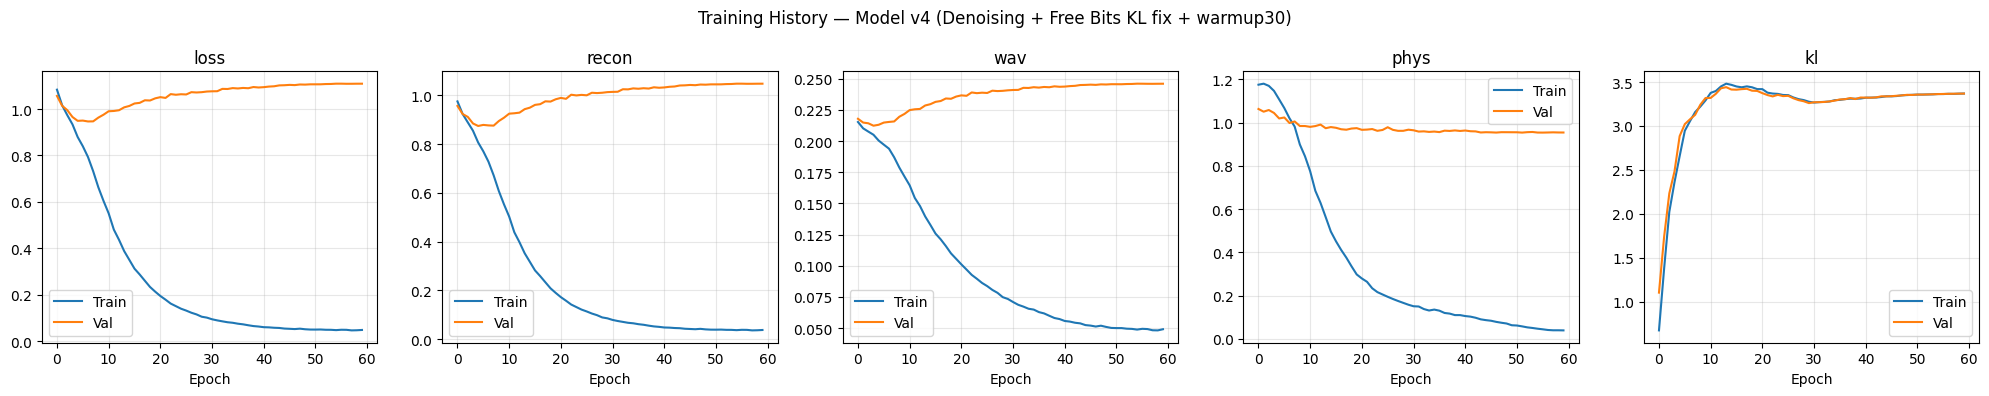

In [15]:
def plot_history(history, title='v4'):
    keys = ['loss','recon','wav','phys','kl']
    fig, axes = plt.subplots(1, len(keys), figsize=(20, 4))
    for ax, k in zip(axes, keys):
        ax.plot([h[k] for h in history['train']], label='Train')
        if history['val']:
            ax.plot([h.get(k,0) for h in history['val']], label='Val')
        ax.set_title(k); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.suptitle(f'Training History — Model {title}')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history, 'v4 (Denoising + Free Bits KL fix + warmup30)')


## 11. 재구성 시각화

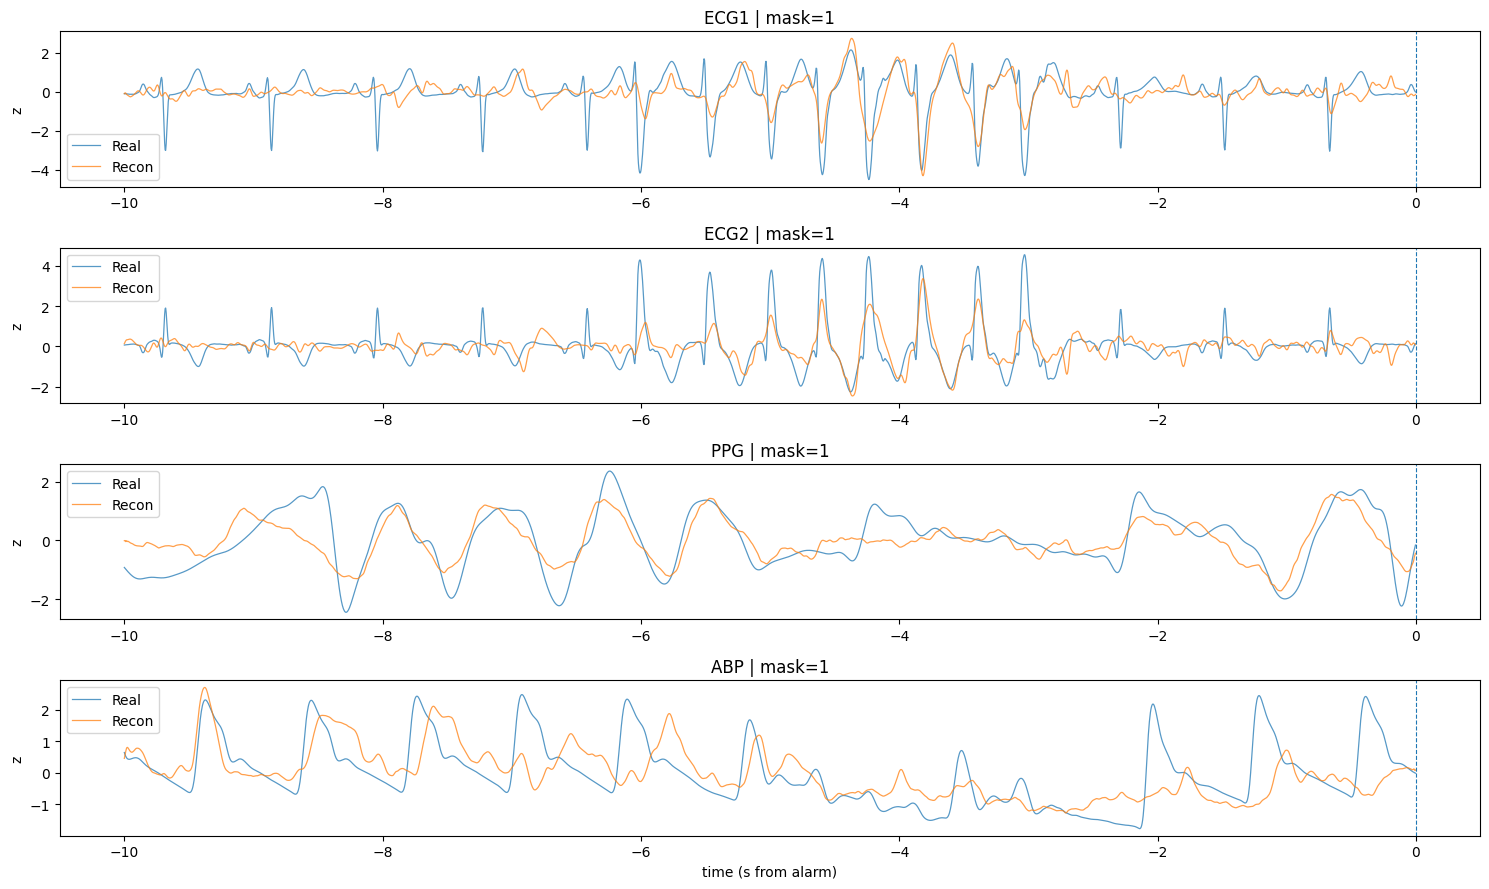

438

In [34]:
@torch.no_grad()
def plot_recon(model, X, y, m, idx=None, true_only=True, fs=250):
    model.eval()
    if idx is None:
        cands = np.where(y.numpy()==1)[0] if true_only else np.arange(len(y))
        idx = int(np.random.choice(cands))
    xb = X[idx:idx+1].to(device)
    yb = y[idx:idx+1].to(device)
    mb = m[idx:idx+1].to(device)
    cb = torch.cat([yb.float().unsqueeze(1), mb.float()], 1)
    xh = model.reconstruct(xb, cb, mb, use_mean=True)
    xn, xhn, mn = xb[0].cpu().numpy(), xh[0].cpu().numpy(), mb[0].cpu().numpy().astype(int)
    t = np.arange(xn.shape[1]) / fs - 10
    fig, axes = plt.subplots(4, 1, figsize=(15, 9))
    for i, (ax, ch) in enumerate(zip(axes, ['ECG1','ECG2','PPG','ABP'])):
        if mn[i]:
            ax.plot(t, xn[i],  lw=0.9, alpha=0.75, label='Real')
            ax.plot(t, xhn[i], lw=0.9, alpha=0.75, label='Recon')
        ax.axvline(0, ls='--', lw=0.8)
        ax.set_title(f'{ch} | mask={mn[i]}'); ax.set_ylabel('z'); ax.legend()
    axes[-1].set_xlabel('time (s from alarm)')
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/reconstruction.png', dpi=150, bbox_inches='tight')
    plt.show(); return idx

plot_recon(model, X_train, y_train, m_train)


## 12. True Alarm 샘플 생성

In [17]:
@torch.no_grad()
def generate(model, true_masks, n, z_scale=0.7, bs=128, device='cuda'):
    model.eval()
    if isinstance(true_masks, np.ndarray):
        true_masks = torch.tensor(true_masks, dtype=torch.float32)
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(true_masks), size=n, replace=True)
    masks = true_masks[idx].float()
    cond  = torch.cat([torch.ones(n, 1), masks], 1)
    outs  = []
    for s in range(0, n, bs):
        cb = cond[s:s+bs].to(device)
        mb = masks[s:s+bs].to(device)
        xb = model.sample_prior(cb, n=cb.size(0), z_scale=z_scale, m_channel=mb)
        outs.append((xb * mb.unsqueeze(-1)).cpu())
    return torch.cat(outs), masks


n_false = int((y_train==0).sum())
n_true  = int((y_train==1).sum())
n_gen   = n_false - n_true

print(f'False: {n_false}, True: {n_true}, 생성: {n_gen}')

X_gen, m_gen = generate(model, m_train[y_train==1], n_gen, device=device)
y_gen = torch.ones(len(X_gen), dtype=torch.long)

print(f'Generated: {X_gen.shape}')
print(f'CVAE sample std: {X_gen.std().item():.4f}  (v3: 0.2427, 목표: ~0.7~1.0)')
print(f'ABP 있는 샘플: {int((m_gen[:,3]==1).sum())} / {len(m_gen)} ({int((m_gen[:,3]==1).sum())/len(m_gen)*100:.1f}%)')

torch.save({
    'X_syn': X_gen, 'y_syn': y_gen, 'm_syn': m_gen,
    'method': 'cvae_v4_classifier_physloss', 'channels': CHANNELS,
}, f'{OUT_DIR}/generated_true_v4_classifier_physloss.pt')
print('저장 완료')


False: 2754, True: 1147, 생성: 1607
Generated: torch.Size([1607, 4, 2500])
CVAE sample std: 0.4896  (v3: 0.2427, 목표: ~0.7~1.0)
ABP 있는 샘플: 605 / 1607 (37.6%)
저장 완료


## 13. 생성 신호 시각화

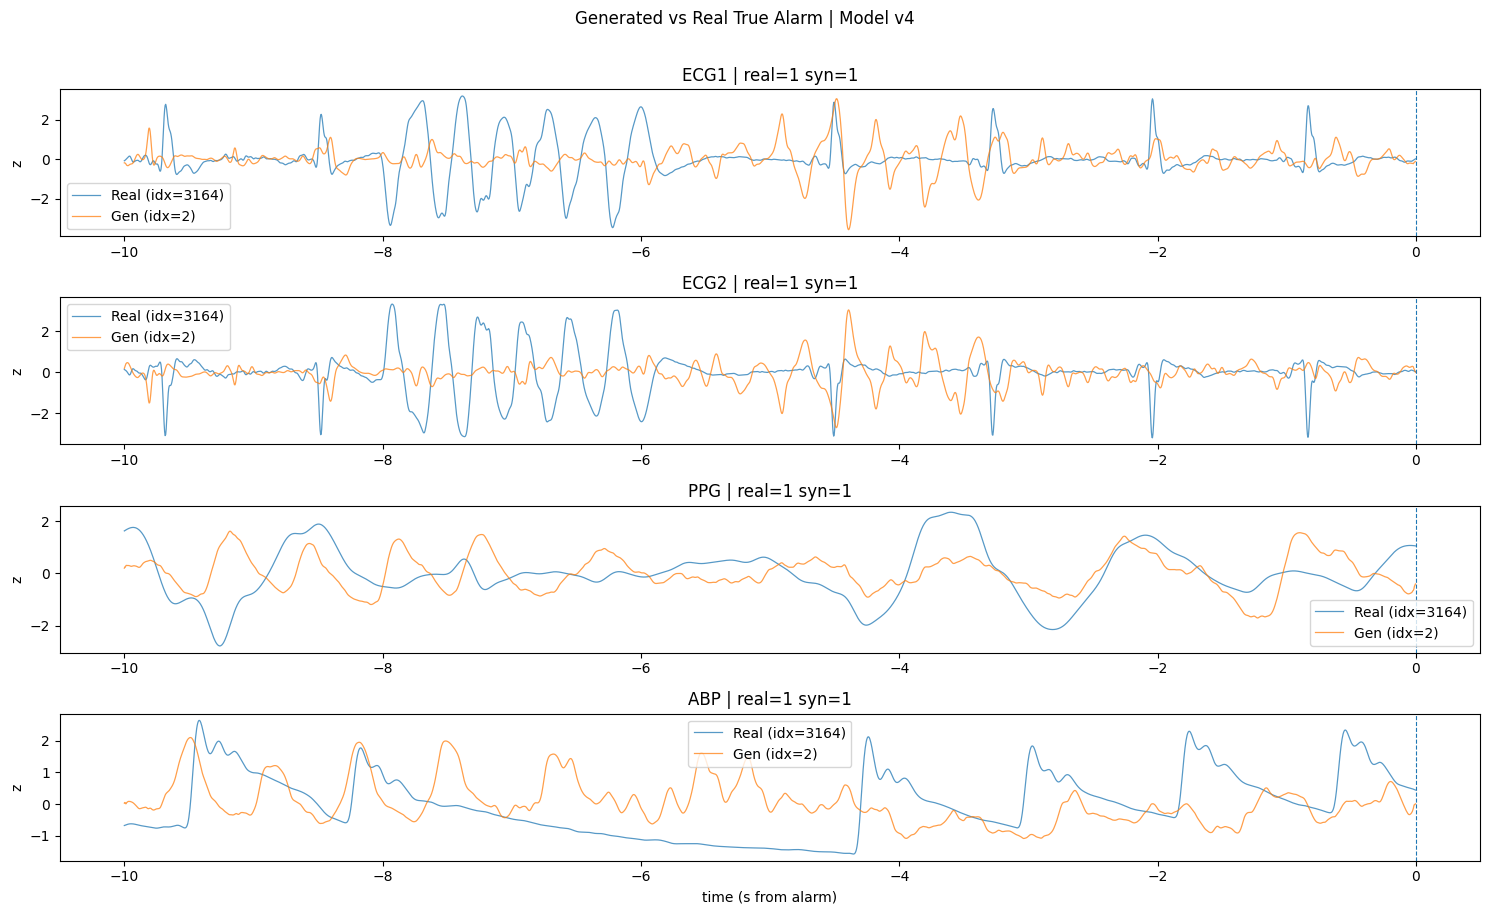

In [30]:
def _to_np(x): return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)

def plot_gen_vs_real(X_syn, m_syn, X_real, y_real, m_real, syn_idx=None, fs=250):
    if syn_idx is None:
        abp_idx = [i for i,m in enumerate(m_syn) if m[3].item()==1]
        syn_idx = abp_idx[0] if abp_idx else 0
    xs, ms = _to_np(X_syn[syn_idx]), _to_np(m_syn[syn_idx]).astype(int)
    y_np, m_np = _to_np(y_real), _to_np(m_real).astype(int)
    ti = np.where(y_np==1)[0]
    matched = [i for i in ti if np.array_equal(m_np[i], ms)]
    ri = int(np.random.choice(matched if matched else ti))
    xr, mr = _to_np(X_real[ri]), _to_np(m_real[ri]).astype(int)
    t = np.arange(xs.shape[1]) / fs - 10
    fig, axes = plt.subplots(4, 1, figsize=(15, 9))
    for i, (ax, ch) in enumerate(zip(axes, ['ECG1','ECG2','PPG','ABP'])):
        if mr[i]: ax.plot(t, xr[i], lw=0.9, alpha=0.75, label=f'Real (idx={ri})')
        if ms[i]: ax.plot(t, xs[i], lw=0.9, alpha=0.75, label=f'Gen (idx={syn_idx})')
        ax.axvline(0, ls='--', lw=0.8)
        ax.set_title(f'{ch} | real={mr[i]} syn={ms[i]}')
        ax.set_ylabel('z'); ax.legend()
    axes[-1].set_xlabel('time (s from alarm)')
    plt.suptitle('Generated vs Real True Alarm | Model v4', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/gen_vs_real.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_gen_vs_real(X_gen, m_gen, X_train, y_train, m_train)


## 14. Latent Space 진단

In [19]:
@torch.no_grad()
def latent_diag(model, X, y, m, n=512, device='cuda'):
    model.eval()
    idx = torch.where(y==1)[0][torch.randperm(int((y==1).sum()))[:n]]
    xb  = X[idx].to(device).float()
    cb  = torch.cat([y[idx].float().unsqueeze(1).to(device),
                     m[idx].float().to(device)], 1)
    mu, logvar = model.encode(xb, cb)
    std = torch.exp(0.5 * logvar)
    print('=== Latent Space 진단 (True Alarm 512개) ===')
    print(f'mu   mean: {mu.mean().item():.4f}  std: {mu.std().item():.4f}')
    print(f'std  mean: {std.mean().item():.4f}  std: {std.std().item():.4f}')
    print(f'logvar mean: {logvar.mean().item():.4f}')
    print()
    print('=== 버전별 비교 ===')
    print('          mu.mean   mu.std   std.mean   logvar.mean   비고')
    print('v1:       -0.0007    0.959     0.184      -3.43        posterior collapse')
    print('v2:       -0.0027    0.508     0.839      -0.596       mu std 붕괴')
    print('v3:       -0.0039    0.637     0.220      -3.119       Free Bits 역효과 + noise aug 오류')
    print(f'v4:       {mu.mean().item():+.4f}   {mu.std().item():.3f}     {std.mean().item():.3f}      {logvar.mean().item():.3f}        <- 현재')
    print()
    print('이상적:   ~0        ~1.0      ~1.0        ~0')
    std_mean = std.mean().item()
    if std_mean < 0.3:
        print('posterior collapse 여전히 있음 (std.mean < 0.3)')
        print('   -> beta_max 낮추거나 free_bits 더 줄이기 검토')
    elif std_mean > 0.6 and mu.std().item() > 0.7:
        print('두 지표 모두 개선됨!')
    else:
        print('부분 개선 — 추가 튜닝 필요')

latent_diag(model, X_train, y_train, m_train, device=device)


=== Latent Space 진단 (True Alarm 512개) ===
mu   mean: -0.0085  std: 1.4798
std  mean: 0.0891  std: 0.0351
logvar mean: -4.9721

=== 버전별 비교 ===
          mu.mean   mu.std   std.mean   logvar.mean   비고
v1:       -0.0007    0.959     0.184      -3.43        posterior collapse
v2:       -0.0027    0.508     0.839      -0.596       mu std 붕괴
v3:       -0.0039    0.637     0.220      -3.119       Free Bits 역효과 + noise aug 오류
v4:       -0.0085   1.480     0.089      -4.972        <- 현재

이상적:   ~0        ~1.0      ~1.0        ~0
posterior collapse 여전히 있음 (std.mean < 0.3)
   -> beta_max 낮추거나 free_bits 더 줄이기 검토


---
## 15. Classifier 정의
### 15-1. 1D-CNN Classifier
채널별 missing mask 처리, 5층 Conv → AdaptiveAvgPool → FC head


In [20]:
class CNN1DClassifier(nn.Module):
    """
    4채널 멀티모달 신호 분류기.
    missing channel mask를 받아 결측 채널을 0으로 처리한 뒤 분류.
    """
    def __init__(self, in_channels=4, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels,  32, 9, stride=2, padding=4), nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Conv1d(32,  64, 9, stride=2, padding=4), nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64, 128, 7, stride=2, padding=3), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128,256, 7, stride=2, padding=3), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256,256, 5, stride=2, padding=2), nn.BatchNorm1d(256), nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2),
        )

    def forward(self, x, m_channel=None):
        if m_channel is not None:
            x = x * m_channel.unsqueeze(-1)
        h = self.pool(self.conv(x)).squeeze(-1)
        return self.head(h)

_test = CNN1DClassifier()
print('CNN1D 출력 shape:', _test(torch.randn(4,4,2500), torch.ones(4,4)).shape)
del _test


CNN1D 출력 shape: torch.Size([4, 2])


### 15-2. FCN Classifier (VTaC NeurIPS 2023 공식 베이스라인)
**구조 (Appendix D)**: Conv×3 + BatchNorm (사이사이) → AdaptiveMaxPool → Dense

VTaC 논문 Table 4에서 Challenge Score 80.08, AUC 0.949로 supervised 중 최고 성능.


In [21]:
class FCNClassifier(nn.Module):
    """
    VTaC NeurIPS 2023 Appendix D 기반 FCN.
    3 Conv layers + BN + AdaptiveMaxPool + Dense
    논문: 'FCN used 3 convolution layers followed by an adaptive pooling layer.
           Between each convolution, batch normalization was used.
           Lastly, adaptive max pooling followed by a dense layer.'
    """
    def __init__(self, in_channels=4, base_ch=128, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            # Conv 1
            nn.Conv1d(in_channels, base_ch,    kernel_size=8, stride=1, padding=4),
            nn.BatchNorm1d(base_ch), nn.ReLU(),
            # Conv 2
            nn.Conv1d(base_ch,     base_ch*2,  kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(base_ch*2), nn.ReLU(),
            # Conv 3
            nn.Conv1d(base_ch*2,   base_ch*2,  kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(base_ch*2), nn.ReLU(),
        )
        self.pool = nn.AdaptiveMaxPool1d(1)   # VTaC 논문: adaptive max pooling
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(base_ch*2, 2),          # dense layer → 2-class
        )

    def forward(self, x, m_channel=None):
        if m_channel is not None:
            x = x * m_channel.unsqueeze(-1)
        h = self.pool(self.conv(x)).squeeze(-1)
        return self.head(h)

_test = FCNClassifier()
print('FCN 출력 shape:', _test(torch.randn(4,4,2500), torch.ones(4,4)).shape)
# 파라미터 수 비교
cnn_params = sum(p.numel() for p in CNN1DClassifier().parameters())
fcn_params = sum(p.numel() for p in FCNClassifier().parameters())
print(f'파라미터 수 — CNN1D: {cnn_params:,} | FCN: {fcn_params:,}')
del _test


FCN 출력 shape: torch.Size([4, 2])
파라미터 수 — CNN1D: 669,346 | FCN: 366,978


## 16. Classifier 학습 함수 + AUPRC / AUROC 평가

In [22]:
def clf_epoch(model, loader, optimizer=None, device='cuda'):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_prob, all_true = 0., [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            x, y, m = [t.to(device) for t in batch]
            x, m = x.float(), m.float()
            logit = model(x, m)
            loss  = F.cross_entropy(logit, y)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
            all_prob.append(F.softmax(logit, 1)[:, 1].detach().cpu())
            all_true.append(y.cpu())
    probs = torch.cat(all_prob).numpy()
    trues = torch.cat(all_true).numpy()
    auprc = average_precision_score(trues, probs)
    auroc = roc_auc_score(trues, probs)
    return total_loss/len(loader), auprc, auroc


def train_classifier(clf, train_loader, val_loader,
                     device='cuda', epochs=40, lr=3e-4,
                     weight_decay=1e-4, patience=8, label='clf'):
    clf = clf.to(device)
    opt   = torch.optim.AdamW(clf.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr*0.01)
    best_auprc, best_state, wait = 0., None, 0
    history = {'tr_loss':[], 'tr_auprc':[], 'val_loss':[], 'val_auprc':[], 'val_auroc':[]}
    for ep in range(1, epochs+1):
        tr_loss, tr_auprc, _           = clf_epoch(clf, train_loader, opt, device)
        val_loss, val_auprc, val_auroc = clf_epoch(clf, val_loader,   None, device)
        sched.step()
        history['tr_loss'].append(tr_loss);    history['tr_auprc'].append(tr_auprc)
        history['val_loss'].append(val_loss);  history['val_auprc'].append(val_auprc)
        history['val_auroc'].append(val_auroc)
        if val_auprc > best_auprc:
            best_auprc = val_auprc
            best_state = {k: v.cpu().clone() for k, v in clf.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  [Early stop] epoch {ep}'); break
        if ep == 1 or ep % 5 == 0:
            print(f'  [{label}] Ep {ep:03d} | tr_auprc={tr_auprc:.4f}'
                  f' | val_auprc={val_auprc:.4f} val_auroc={val_auroc:.4f}')
    clf.load_state_dict(best_state)
    print(f'  [{label}] Best Val AUPRC: {best_auprc:.4f}')
    return clf, history


def evaluate_clf(clf, loader, device='cuda', label=''):
    from sklearn.metrics import precision_recall_curve, f1_score
    clf.eval()
    all_prob, all_true = [], []
    with torch.no_grad():
        for x, y, m in loader:
            x, m = x.float().to(device), m.float().to(device)
            all_prob.append(F.softmax(clf(x, m), 1)[:, 1].cpu())
            all_true.append(y)
    probs = torch.cat(all_prob).numpy()
    trues = torch.cat(all_true).numpy()
    auprc = average_precision_score(trues, probs)
    auroc = roc_auc_score(trues, probs)
    prec, rec, thr = precision_recall_curve(trues, probs)
    f1s = 2*prec*rec/(prec+rec+1e-8)
    best_f1 = float(f1s.max())
    print(f'[{label}] Test AUPRC={auprc:.4f}  AUROC={auroc:.4f}  Best-F1={best_f1:.4f}')
    return {'auprc': auprc, 'auroc': auroc, 'best_f1': best_f1,
            'probs': probs, 'trues': trues, 'prec': prec, 'rec': rec}


## 17. DataLoader 공통 구성

In [23]:
clf_train_ds_base = TensorDataset(X_train, y_train, m_train)
clf_val_ds        = TensorDataset(X_val,   y_val,   m_val)
clf_test_ds       = TensorDataset(X_test,  y_test,  m_test)

cw_clf       = 1.0 / torch.bincount(y_train, minlength=2).float()
sampler_base = WeightedRandomSampler(cw_clf[y_train], len(y_train), replacement=True)

clf_train_loader_base = DataLoader(clf_train_ds_base, batch_size=64,
                                   sampler=sampler_base, num_workers=2, pin_memory=True)
clf_val_loader  = DataLoader(clf_val_ds,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
clf_test_loader = DataLoader(clf_test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(clf_train_ds_base)} | Val: {len(clf_val_ds)} | Test: {len(clf_test_ds)}')


Train: 3901 | Val: 481 | Test: 465


## 18. Augmented DataLoader (CVAE 생성 True Alarm 추가)

In [24]:
gen_data = torch.load(f'{OUT_DIR}/generated_true_v4_classifier_physloss.pt',
                      map_location='cpu', weights_only=False)
X_syn = gen_data['X_syn'].float()
y_syn = gen_data['y_syn'].long()
m_syn = gen_data['m_syn'].float()
print(f'생성 데이터: {X_syn.shape} | label: {torch.bincount(y_syn).tolist()}')

X_aug = torch.cat([X_train, X_syn], 0)
y_aug = torch.cat([y_train, y_syn], 0)
m_aug = torch.cat([m_train, m_syn], 0)
print(f'Augmented train: {len(X_aug)} | True 비율: {float(y_aug.sum())/len(y_aug)*100:.1f}%')

clf_train_ds_aug = TensorDataset(X_aug, y_aug, m_aug)
cw_aug      = 1.0 / torch.bincount(y_aug, minlength=2).float()
sampler_aug = WeightedRandomSampler(cw_aug[y_aug], len(y_aug), replacement=True)
clf_train_loader_aug = DataLoader(clf_train_ds_aug, batch_size=64,
                                  sampler=sampler_aug, num_workers=2, pin_memory=True)


생성 데이터: torch.Size([1607, 4, 2500]) | label: [0, 1607]
Augmented train: 5508 | True 비율: 50.0%


## 19. CNN1D — Baseline vs Augmented

In [25]:
print('\n=== [CNN1D] Baseline ===')
set_seed(SEED)
cnn_base = CNN1DClassifier(in_channels=4, dropout=0.3)
cnn_base, hist_cnn_base = train_classifier(
    cnn_base, clf_train_loader_base, clf_val_loader,
    device=device, epochs=40, lr=3e-4, weight_decay=1e-4, patience=8, label='CNN-Base')
res_cnn_base = evaluate_clf(cnn_base, clf_test_loader, device=device, label='CNN1D Baseline')

print('\n=== [CNN1D] CVAE-Augmented ===')
set_seed(SEED)
cnn_aug = CNN1DClassifier(in_channels=4, dropout=0.3)
cnn_aug, hist_cnn_aug = train_classifier(
    cnn_aug, clf_train_loader_aug, clf_val_loader,
    device=device, epochs=40, lr=3e-4, weight_decay=1e-4, patience=8, label='CNN-Aug')
res_cnn_aug = evaluate_clf(cnn_aug, clf_test_loader, device=device, label='CNN1D CVAE-Aug')



=== [CNN1D] Baseline ===
  [CNN-Base] Ep 001 | tr_auprc=0.8085 | val_auprc=0.7080 val_auroc=0.8824
  [CNN-Base] Ep 005 | tr_auprc=0.9431 | val_auprc=0.7899 val_auroc=0.9030
  [Early stop] epoch 10
  [CNN-Base] Best Val AUPRC: 0.8428
[CNN1D Baseline] Test AUPRC=0.7447  AUROC=0.8947  Best-F1=0.7375

=== [CNN1D] CVAE-Augmented ===
  [CNN-Aug] Ep 001 | tr_auprc=0.9169 | val_auprc=0.5695 val_auroc=0.8040
  [CNN-Aug] Ep 005 | tr_auprc=0.9754 | val_auprc=0.7874 val_auroc=0.9121
  [CNN-Aug] Ep 010 | tr_auprc=0.9898 | val_auprc=0.7908 val_auroc=0.9132
  [Early stop] epoch 11
  [CNN-Aug] Best Val AUPRC: 0.8174
[CNN1D CVAE-Aug] Test AUPRC=0.7912  AUROC=0.8955  Best-F1=0.7447


## 20. FCN — Baseline vs Augmented (VTaC 공식 베이스라인)

In [26]:
print('\n=== [FCN] Baseline ===')
set_seed(SEED)
fcn_base = FCNClassifier(in_channels=4, base_ch=128, dropout=0.2)
fcn_base, hist_fcn_base = train_classifier(
    fcn_base, clf_train_loader_base, clf_val_loader,
    device=device, epochs=40, lr=3e-4, weight_decay=1e-4, patience=8, label='FCN-Base')
res_fcn_base = evaluate_clf(fcn_base, clf_test_loader, device=device, label='FCN Baseline')

print('\n=== [FCN] CVAE-Augmented ===')
set_seed(SEED)
fcn_aug = FCNClassifier(in_channels=4, base_ch=128, dropout=0.2)
fcn_aug, hist_fcn_aug = train_classifier(
    fcn_aug, clf_train_loader_aug, clf_val_loader,
    device=device, epochs=40, lr=3e-4, weight_decay=1e-4, patience=8, label='FCN-Aug')
res_fcn_aug = evaluate_clf(fcn_aug, clf_test_loader, device=device, label='FCN CVAE-Aug')



=== [FCN] Baseline ===
  [FCN-Base] Ep 001 | tr_auprc=0.6411 | val_auprc=0.6217 val_auroc=0.8233
  [FCN-Base] Ep 005 | tr_auprc=0.8597 | val_auprc=0.7190 val_auroc=0.8857
  [FCN-Base] Ep 010 | tr_auprc=0.9034 | val_auprc=0.7386 val_auroc=0.9014
  [FCN-Base] Ep 015 | tr_auprc=0.9433 | val_auprc=0.7362 val_auroc=0.9000
  [FCN-Base] Ep 020 | tr_auprc=0.9593 | val_auprc=0.7464 val_auroc=0.9067
  [Early stop] epoch 22
  [FCN-Base] Best Val AUPRC: 0.7602
[FCN Baseline] Test AUPRC=0.7556  AUROC=0.8859  Best-F1=0.7267

=== [FCN] CVAE-Augmented ===
  [FCN-Aug] Ep 001 | tr_auprc=0.8511 | val_auprc=0.5949 val_auroc=0.8078
  [FCN-Aug] Ep 005 | tr_auprc=0.9472 | val_auprc=0.6545 val_auroc=0.8586
  [FCN-Aug] Ep 010 | tr_auprc=0.9635 | val_auprc=0.6938 val_auroc=0.8834
  [FCN-Aug] Ep 015 | tr_auprc=0.9694 | val_auprc=0.7207 val_auroc=0.8888
  [FCN-Aug] Ep 020 | tr_auprc=0.9801 | val_auprc=0.7192 val_auroc=0.8970
  [FCN-Aug] Ep 025 | tr_auprc=0.9870 | val_auprc=0.7479 val_auroc=0.9040
  [FCN-Aug] Ep 

## 21. 최종 비교 시각화 — CNN1D / FCN × Baseline / CVAE-Aug

/tmp/ipykernel_577/922731941.py:62: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_577/922731941.py:62: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_577/922731941.py:63: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUT_DIR}/clf_comparison_fcn.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_577/922731941.py:63: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUT_DIR}/clf_comparison_fcn.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYL

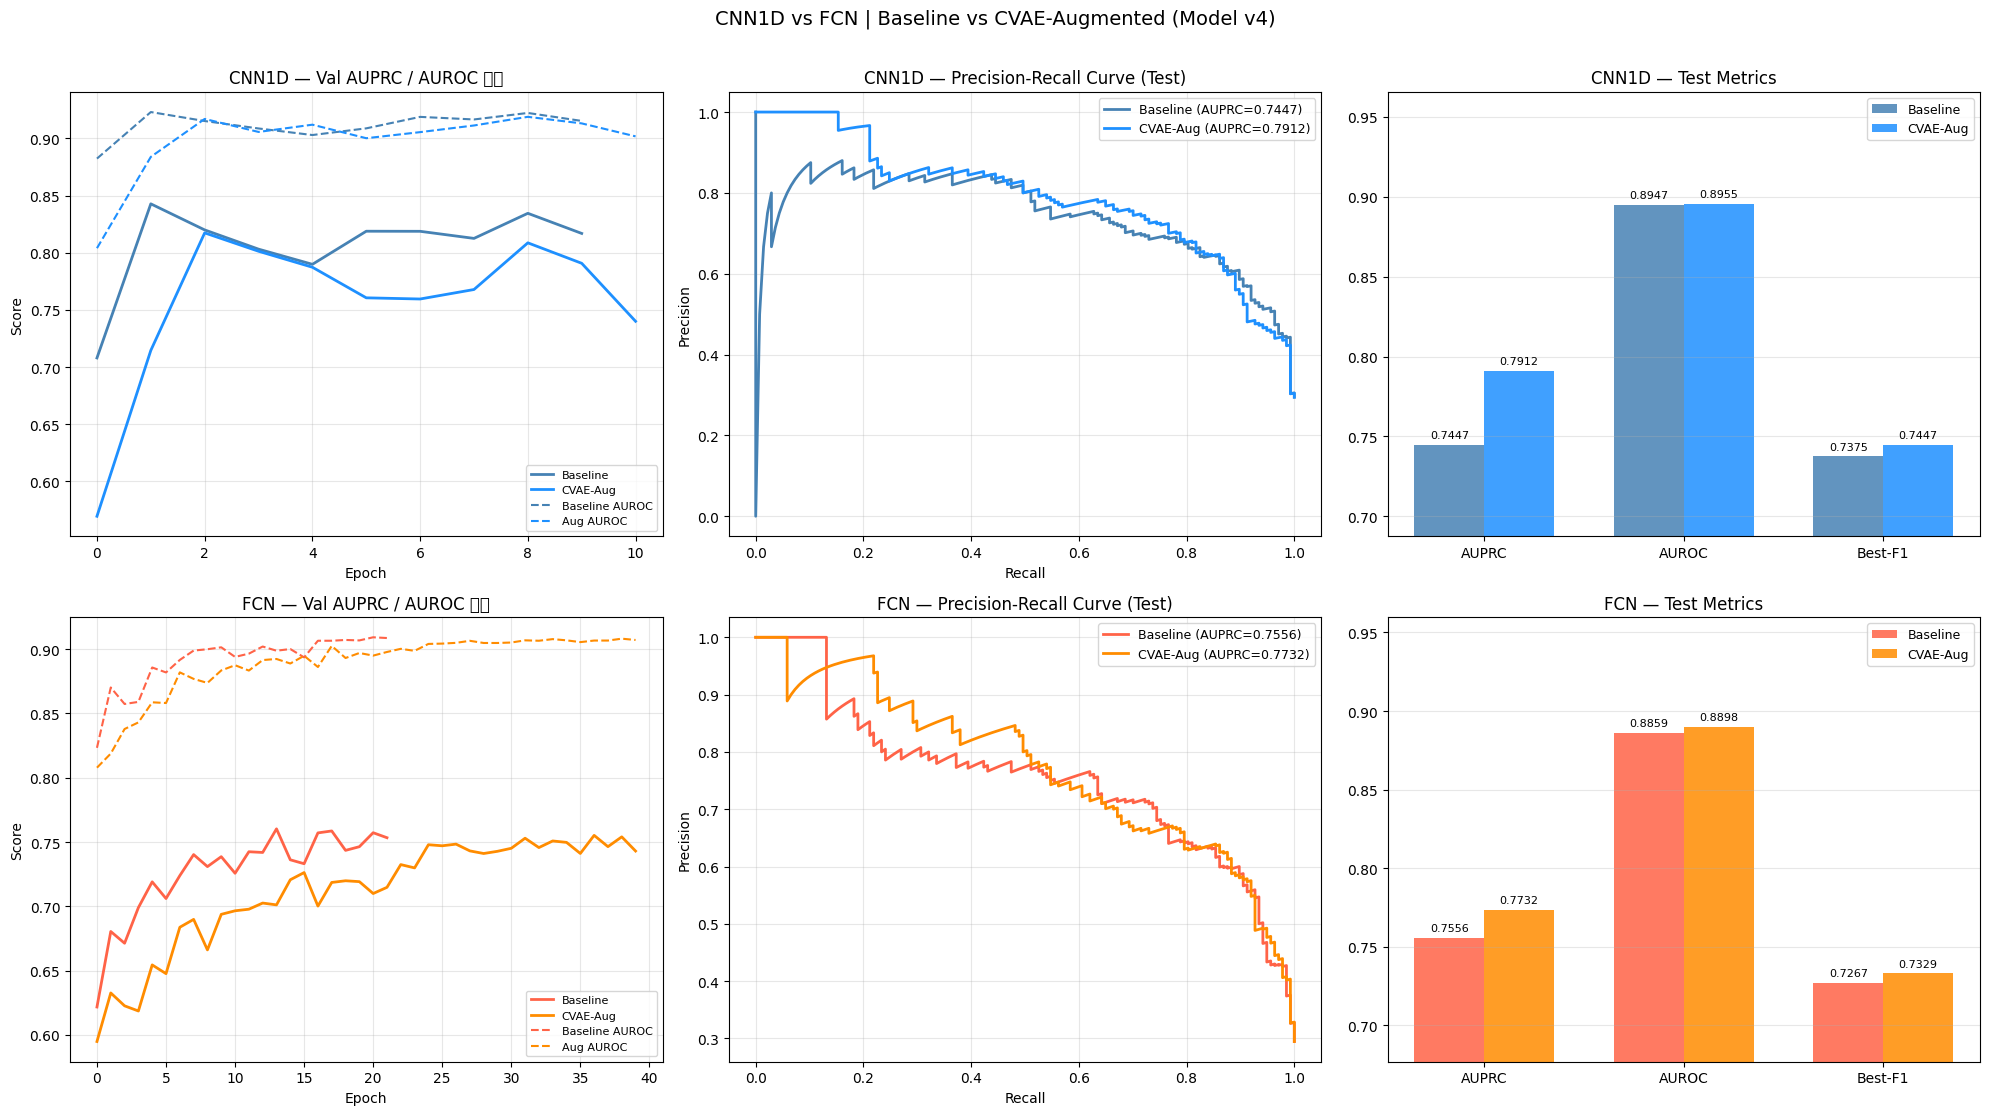

In [27]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

results = {
    'CNN1D\nBaseline': res_cnn_base,
    'CNN1D\nCVAE-Aug': res_cnn_aug,
    'FCN\nBaseline':   res_fcn_base,
    'FCN\nCVAE-Aug':   res_fcn_aug,
}
colors = {'CNN1D\nBaseline':'steelblue', 'CNN1D\nCVAE-Aug':'dodgerblue',
          'FCN\nBaseline':'tomato',      'FCN\nCVAE-Aug':'darkorange'}

# ── Row 0: CNN1D ─────────────────────────────────────────────────────────────
for row, (clf_name, res_b, res_a, hist_b, hist_a) in enumerate([
    ('CNN1D', res_cnn_base, res_cnn_aug, hist_cnn_base, hist_cnn_aug),
    ('FCN',   res_fcn_base, res_fcn_aug, hist_fcn_base, hist_fcn_aug),
]):
    # (1) Val AUPRC 곡선
    ax = axes[row][0]
    ax.plot(hist_b['val_auprc'], label='Baseline',  color='steelblue' if row==0 else 'tomato',    lw=2)
    ax.plot(hist_a['val_auprc'], label='CVAE-Aug',  color='dodgerblue' if row==0 else 'darkorange', lw=2)
    ax.plot(hist_b['val_auroc'], label='Baseline AUROC',  color='steelblue' if row==0 else 'tomato',    lw=1.5, ls='--')
    ax.plot(hist_a['val_auroc'], label='Aug AUROC',        color='dodgerblue' if row==0 else 'darkorange', lw=1.5, ls='--')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Score')
    ax.set_title(f'{clf_name} — Val AUPRC / AUROC 곡선')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # (2) PR Curve
    ax = axes[row][1]
    for res, label, c in [(res_b,'Baseline','steelblue' if row==0 else 'tomato'),
                           (res_a,'CVAE-Aug','dodgerblue' if row==0 else 'darkorange')]:
        prec, rec, _ = precision_recall_curve(res['trues'], res['probs'])
        ax.plot(rec, prec, label=f"{label} (AUPRC={res['auprc']:.4f})", color=c, lw=2)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{clf_name} — Precision-Recall Curve (Test)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # (3) 지표 막대
    ax = axes[row][2]
    metrics  = ['AUPRC', 'AUROC', 'Best-F1']
    base_val = [res_b['auprc'], res_b['auroc'], res_b['best_f1']]
    aug_val  = [res_a['auprc'], res_a['auroc'], res_a['best_f1']]
    x = np.arange(len(metrics)); w = 0.35
    c1 = 'steelblue' if row==0 else 'tomato'
    c2 = 'dodgerblue' if row==0 else 'darkorange'
    bars1 = ax.bar(x - w/2, base_val, w, label='Baseline', color=c1, alpha=0.85)
    bars2 = ax.bar(x + w/2, aug_val,  w, label='CVAE-Aug', color=c2, alpha=0.85)
    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                    f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
    all_v = base_val + aug_val
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylim(max(0, min(all_v)-0.05), min(1.0, max(all_v)+0.07))
    ax.set_title(f'{clf_name} — Test Metrics')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('CNN1D vs FCN | Baseline vs CVAE-Augmented (Model v4)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/clf_comparison_fcn.png', dpi=150, bbox_inches='tight')
plt.show()


## 22. 최종 요약 출력

In [28]:
print('\n' + '='*65)
print(f'  Model v4 + Classifier Phys Loss CVAE Augmentation 효과 — Classifier 비교')
print('='*65)
print(f'  {"":20s}  {"AUPRC":>8}  {"AUROC":>8}  {"Best-F1":>8}')
print('-'*65)

for label, res in [('CNN1D Baseline', res_cnn_base), ('CNN1D CVAE-Aug', res_cnn_aug),
                   ('FCN   Baseline', res_fcn_base), ('FCN   CVAE-Aug', res_fcn_aug)]:
    print(f'  {label:20s}  {res["auprc"]:8.4f}  {res["auroc"]:8.4f}  {res["best_f1"]:8.4f}')

print('-'*65)
d_cnn = res_cnn_aug['auprc'] - res_cnn_base['auprc']
d_fcn = res_fcn_aug['auprc'] - res_fcn_base['auprc']
d_cnn_roc = res_cnn_aug['auroc'] - res_cnn_base['auroc']
d_fcn_roc = res_fcn_aug['auroc'] - res_fcn_base['auroc']
print(f'  {"Δ CNN1D":20s}  {d_cnn:+8.4f}  {d_cnn_roc:+8.4f}')
print(f'  {"Δ FCN":20s}  {d_fcn:+8.4f}  {d_fcn_roc:+8.4f}')
print('='*65)

torch.save({
    'res_cnn_base': res_cnn_base, 'res_cnn_aug': res_cnn_aug,
    'res_fcn_base': res_fcn_base, 'res_fcn_aug': res_fcn_aug,
    'delta_cnn_auprc': d_cnn,     'delta_fcn_auprc': d_fcn,
}, f'{OUT_DIR}/clf_results_v4_fcn.pt')
print(f'저장 완료: {OUT_DIR}/clf_results_v4_fcn.pt')



  Model v4 + Classifier Phys Loss CVAE Augmentation 효과 — Classifier 비교
                           AUPRC     AUROC   Best-F1
-----------------------------------------------------------------
  CNN1D Baseline          0.7447    0.8947    0.7375
  CNN1D CVAE-Aug          0.7912    0.8955    0.7447
  FCN   Baseline          0.7556    0.8859    0.7267
  FCN   CVAE-Aug          0.7732    0.8898    0.7329
-----------------------------------------------------------------
  Δ CNN1D                +0.0464   +0.0008
  Δ FCN                  +0.0176   +0.0039
저장 완료: /content/drive/MyDrive/vtac_project/outputs/cvae_v4_classifier_physloss/clf_results_v4_fcn.pt


In [35]:
# ============================================================
# FINAL PREP BLOCK FOR EVAL NOTEBOOK
# Reload BEST checkpoint -> regenerate fixed synthetic samples
# -> save proposed synthetic payload -> create eval manifest
# ============================================================

import os
import json
import glob
import random
import numpy as np
import torch

# ------------------------------------------------------------
# 0. Core paths
# ------------------------------------------------------------
OUT_DIR = "/content/drive/MyDrive/vtac_project/outputs/cvae_v4_classifier_physloss"
os.makedirs(OUT_DIR, exist_ok=True)

SAVE_PATH = f"{OUT_DIR}/cvae_v4_classifier_physloss_best.pt"
PROP_SYN_PATH = f"{OUT_DIR}/generated_true_v4_classifier_physloss.pt"
PROP_GEN_MANIFEST_PATH = f"{OUT_DIR}/generation_manifest_classifier_physloss.json"

EVAL_ROOT = "/content/drive/MyDrive/vtac_project/evaluation"
os.makedirs(EVAL_ROOT, exist_ok=True)
EVAL_MANIFEST_PATH = f"{EVAL_ROOT}/eval_manifest.json"

REAL_DATA_DIR = "/content/drive/MyDrive/vtac_preprocessed_10s_v2"
TRAIN_PATH = f"{REAL_DATA_DIR}/train_10s_v2.pt"
VAL_PATH   = f"{REAL_DATA_DIR}/val_10s_v2.pt"
TEST_PATH  = f"{REAL_DATA_DIR}/test_10s_v2.pt"

print("OUT_DIR:", OUT_DIR)
print("SAVE_PATH:", SAVE_PATH)
print("PROP_SYN_PATH:", PROP_SYN_PATH)
print("EVAL_MANIFEST_PATH:", EVAL_MANIFEST_PATH)

assert os.path.exists(SAVE_PATH), f"Best checkpoint 없음: {SAVE_PATH}"
assert os.path.exists(TRAIN_PATH), f"Train data 없음: {TRAIN_PATH}"
assert os.path.exists(VAL_PATH), f"Val data 없음: {VAL_PATH}"
assert os.path.exists(TEST_PATH), f"Test data 없음: {TEST_PATH}"

# ------------------------------------------------------------
# 1. Fix generation seed
# ------------------------------------------------------------
GEN_SEED = 42
SEED = GEN_SEED  # generate() 함수가 global SEED를 쓰므로 명시적으로 세팅

random.seed(GEN_SEED)
np.random.seed(GEN_SEED)
torch.manual_seed(GEN_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GEN_SEED)

# ------------------------------------------------------------
# 2. Reload BEST checkpoint from disk
# ------------------------------------------------------------
ckpt = torch.load(SAVE_PATH, map_location=device)

model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()

best_epoch = ckpt.get("epoch", None)
best_val = ckpt.get("best_val", None)

# 혹시 best_val이 없으면 history에서 복원
if best_val is None and "history" in ckpt and best_epoch is not None:
    try:
        best_val = ckpt["history"]["val"][best_epoch - 1]["loss"]
    except Exception:
        best_val = None

print("\n[Best checkpoint loaded]")
print("best_epoch:", best_epoch)
print("best_val:", best_val)

# ------------------------------------------------------------
# 3. Determine synthetic sample count
#    true class를 false class 수에 맞게 oversampling
# ------------------------------------------------------------
y_train_cpu = y_train.detach().cpu().long()
m_train_cpu = m_train.detach().cpu().float()

n_false = int((y_train_cpu == 0).sum().item())
n_true  = int((y_train_cpu == 1).sum().item())
n_gen   = n_false - n_true

true_mask_pool = m_train_cpu[y_train_cpu == 1]

print("\n[Train class count]")
print("false:", n_false)
print("true :", n_true)
print("n_gen:", n_gen)
print("true_mask_pool:", true_mask_pool.shape)

assert n_gen > 0, "n_gen <= 0. train set class count 확인 필요."
assert len(true_mask_pool) > 0, "true_mask_pool이 비었음. y_train 확인 필요."

# ------------------------------------------------------------
# 4. Generate synthetic true samples from BEST model
# ------------------------------------------------------------
Z_SCALE = 0.7

with torch.no_grad():
    X_gen, m_gen = generate(
        model=model,
        true_masks=true_mask_pool,
        n=n_gen,
        z_scale=Z_SCALE,
        bs=128,
        device=device,
    )

X_gen = X_gen.detach().cpu().float()
m_gen = m_gen.detach().cpu().float()
y_gen = torch.ones(X_gen.size(0), dtype=torch.long)

# final safety masking
X_gen = X_gen * m_gen.unsqueeze(-1)

channels_to_save = CHANNELS if "CHANNELS" in globals() else ["ECG1", "ECG2", "PPG", "ABP"]

print("\n[Generated synthetic from BEST checkpoint]")
print("X_gen:", X_gen.shape)
print("y_gen:", y_gen.shape)
print("m_gen:", m_gen.shape)
print("X mean:", float(X_gen.mean()))
print("X std :", float(X_gen.std()))
print("X min :", float(X_gen.min()))
print("X max :", float(X_gen.max()))
print("mask unique:", torch.unique(m_gen))

# ------------------------------------------------------------
# 5. Save proposed synthetic payload
# ------------------------------------------------------------
prop_payload = {
    "X_syn": X_gen,
    "y_syn": y_gen,
    "m_syn": m_gen,

    "method": "cvae_v4_classifier_physloss",
    "source_ckpt": SAVE_PATH,
    "best_epoch": best_epoch,
    "best_val": float(best_val) if best_val is not None else None,

    "channels": channels_to_save,
    "window_sec": [-10, 0],
    "fs": 250,

    "n_false_train": n_false,
    "n_true_train": n_true,
    "n_generated": n_gen,
    "z_scale": Z_SCALE,
    "seed": GEN_SEED,

    "note": "Synthetic true VT samples generated after explicitly reloading the best validation checkpoint from disk.",
}

torch.save(prop_payload, PROP_SYN_PATH)

# ------------------------------------------------------------
# 6. Save proposed generation manifest
# ------------------------------------------------------------
prop_gen_manifest = {
    "method": "cvae_v4_classifier_physloss",
    "source_ckpt": SAVE_PATH,
    "synthetic_path": PROP_SYN_PATH,
    "best_epoch": int(best_epoch) if best_epoch is not None else None,
    "best_val": float(best_val) if best_val is not None else None,
    "channels": channels_to_save,
    "window_sec": [-10, 0],
    "fs": 250,
    "n_false_train": n_false,
    "n_true_train": n_true,
    "n_generated": n_gen,
    "z_scale": Z_SCALE,
    "seed": GEN_SEED,
    "X_syn_shape": list(X_gen.shape),
    "y_syn_shape": list(y_gen.shape),
    "m_syn_shape": list(m_gen.shape),
}

with open(PROP_GEN_MANIFEST_PATH, "w") as f:
    json.dump(prop_gen_manifest, f, indent=2)

# ------------------------------------------------------------
# 7. Try to find vanilla/baseline synthetic file
#    못 찾으면 eval notebook에서 직접 경로 수정하면 됨.
# ------------------------------------------------------------
candidate_vanilla_paths = [
    "/content/drive/MyDrive/vtac_project/outputs/cvae_v4_baseline/generated_true_v4_baseline.pt",
    "/content/drive/MyDrive/vtac_project/outputs/model_v4_baseline/generated_true_v4.pt",
    "/content/drive/MyDrive/vtac_project/outputs/model_v4_baseline/generated_true_v4_baseline.pt",
    "/content/drive/MyDrive/vtac_project/outputs/cvae_v4_corrloss/generated_true_v4_corrloss.pt",
]

found_vanilla = None
for p in candidate_vanilla_paths:
    if os.path.exists(p):
        found_vanilla = p
        break

if found_vanilla is None:
    all_generated = glob.glob("/content/drive/MyDrive/vtac_project/outputs/**/generated*true*.pt", recursive=True)
    all_generated = [p for p in all_generated if "classifier_physloss" not in p]
    if len(all_generated) > 0:
        found_vanilla = all_generated[0]

print("\n[Vanilla synthetic path]")
if found_vanilla is None:
    print("⚠️ Vanilla synthetic 파일을 못 찾음. eval_manifest.json에서 vanilla_cvae 경로를 나중에 직접 수정해야 함.")
else:
    print(found_vanilla)

# ------------------------------------------------------------
# 8. Create eval manifest
# ------------------------------------------------------------
eval_manifest = {
    "real_data": {
        "train": TRAIN_PATH,
        "val": VAL_PATH,
        "test": TEST_PATH,
    },
    "synthetic_data": {
        "vanilla_cvae": found_vanilla,
        "proposed_classifier_physloss_cvae": PROP_SYN_PATH,
    },
    "checkpoints": {
        "proposed_classifier_physloss_cvae": SAVE_PATH,
    },
    "evaluation_output_dir": EVAL_ROOT,
    "channels": channels_to_save,
    "window_sec": [-10, 0],
    "fs": 250,
    "notes": {
        "proposed": "Generated from best validation checkpoint after explicit disk reload.",
        "utility_eval": "Use real-only, real+vanilla synthetic, real+proposed synthetic.",
        "smote": "Apply SMOTE only to engineered feature vectors, not raw waveform CNN input.",
        "realism_eval": "Use waveform plot, spectrum, ECG-pulse consistency, PCA/UMAP, feature-space MMD.",
    },
}

with open(EVAL_MANIFEST_PATH, "w") as f:
    json.dump(eval_manifest, f, indent=2)

# ------------------------------------------------------------
# 9. Reload checks
# ------------------------------------------------------------
loaded_prop = torch.load(PROP_SYN_PATH, map_location="cpu")

print("\n[Reload check: proposed synthetic]")
print("keys:", loaded_prop.keys())
print("X_syn:", loaded_prop["X_syn"].shape)
print("y_syn:", loaded_prop["y_syn"].shape)
print("m_syn:", loaded_prop["m_syn"].shape)
print("method:", loaded_prop.get("method"))
print("source_ckpt:", loaded_prop.get("source_ckpt"))
print("best_epoch:", loaded_prop.get("best_epoch"))
print("best_val:", loaded_prop.get("best_val"))
print("z_scale:", loaded_prop.get("z_scale"))
print("seed:", loaded_prop.get("seed"))

print("\n[Saved files]")
print("proposed ckpt      :", SAVE_PATH)
print("proposed synthetic :", PROP_SYN_PATH)
print("generation manifest:", PROP_GEN_MANIFEST_PATH)
print("eval manifest      :", EVAL_MANIFEST_PATH)

print("\n[OUT_DIR files]")
!ls -lh "{OUT_DIR}"

print("\n[EVAL_ROOT files]")
!ls -lh "{EVAL_ROOT}"

OUT_DIR: /content/drive/MyDrive/vtac_project/outputs/cvae_v4_classifier_physloss
SAVE_PATH: /content/drive/MyDrive/vtac_project/outputs/cvae_v4_classifier_physloss/cvae_v4_classifier_physloss_best.pt
PROP_SYN_PATH: /content/drive/MyDrive/vtac_project/outputs/cvae_v4_classifier_physloss/generated_true_v4_classifier_physloss.pt
EVAL_MANIFEST_PATH: /content/drive/MyDrive/vtac_project/evaluation/eval_manifest.json

[Best checkpoint loaded]
best_epoch: 7
best_val: 0.9464195047247682

[Train class count]
false: 2754
true : 1147
n_gen: 1607
true_mask_pool: torch.Size([1147, 4])

[Generated synthetic from BEST checkpoint]
X_gen: torch.Size([1607, 4, 2500])
y_gen: torch.Size([1607])
m_gen: torch.Size([1607, 4])
X mean: 0.020107029005885124
X std : 0.4909761846065521
X min : -4.0535359382629395
X max : 4.409595966339111
mask unique: tensor([0., 1.])

[Vanilla synthetic path]
/content/drive/MyDrive/vtac_project/outputs/proposed_cvae_concat/generated_true_posterior_guided_multibranch_concat.pt

[R